**Author:** Steve Landry Ndjock

  **Python version:**  3.x

In [1]:
%matplotlib inline

# Core libraries
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
)

### Data Preparation

In [2]:
df_WTout = pd.read_csv("cmi_internet_WT_outlier_New_features.csv")
df_WTout.drop(columns=['sii','PCIAT-PCIAT_Total'], inplace=True, errors='ignore')

In [3]:
df_WTout

,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,...,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,Physical-BMI_New,FGC_SitReach_Avg,FGC_Grip_Avg,PAQ_Total,Endurance_Total_Sec
0,Fall,5.0,0.0,Winter,51.00,Fall,46.000,50.8,26.000,73.90,...,Fall,50.55,71.80,Fall,3,16.877316,6.5,12.3225,2.006,448.0
1,Summer,9.0,0.0,Spring,62.55,Fall,48.000,46.0,22.000,75.00,...,Fall,46.00,64.00,Summer,0,14.035590,11.0,20.6250,2.010,334.0
2,Summer,10.0,1.0,Fall,71.00,Fall,56.500,75.6,25.400,65.00,...,Fall,38.00,54.00,Summer,2,16.648696,10.0,12.4500,2.009,453.0
3,Winter,9.0,0.0,Fall,71.00,Summer,56.000,81.6,26.000,60.00,...,Summer,31.00,45.00,Winter,0,18.292347,7.0,20.6250,2.010,577.0
4,Spring,18.0,1.0,Summer,65.00,Spring,55.003,77.0,26.000,68.00,...,Fall,41.60,61.40,Spring,1,17.894545,9.1,21.5525,1.040,460.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8455,Spring,7.0,1.0,Spring,65.15,Fall,46.070,49.0,22.250,58.50,...,Summer,38.50,55.00,Spring,0,16.229868,7.0,18.0750,2.000,547.7
8456,Winter,10.0,1.0,Spring,69.50,Winter,56.130,47.8,28.500,66.00,...,Winter,40.50,56.95,Winter,0,10.665793,5.0,13.5750,2.000,451.5
8457,Winter,10.0,1.0,Winter,70.00,Winter,49.560,47.2,25.635,63.50,...,Winter,43.75,60.75,Spring,2,13.509359,9.5,21.0375,2.004,528.0
8458,Fall,15.0,1.0,Spring,55.50,Spring,63.790,99.5,31.100,67.70,...,Winter,39.80,56.15,Fall,1,17.189894,10.5,24.4700,2.000,478.0


In [4]:
df_original = pd.read_csv("dm2_25_26_dataset_tabular/DM2_project/cmi_internet.csv")
df = df_WTout.copy() 

In [5]:
def encoder_labels_categoriques(df):
    """
    Prend un DataFrame en entrée, convertit les variables catégoriques 
    en nombres entiers (0, 1, 2, 3...) dans la même colonne, et retourne le DataFrame.
    """
    # 1. Copier le dataset pour éviter de modifier l'original
    df_encode = df.copy()
    
    # 2. Identifier les colonnes contenant du texte
    colonnes_categoriques = df_encode.select_dtypes(include=['object', 'category']).columns.tolist()
    
    if not colonnes_categoriques:
        print("Aucune colonne catégorique trouvée.")
        return df_encode
    
    # 3. Remplacer le texte par des codes numériques
    for colonne in colonnes_categoriques:
        # Convertit en type catégorie, puis récupère les codes numériques
        df_encode[colonne] = df_encode[colonne].astype('category').cat.codes
        
    return df_encode

In [6]:
df = encoder_labels_categoriques(df)

In [7]:
# 1. Identifier les colonnes qui commencent par "PCIAT-PCIAT_"
columns2remove = [c for c in df.columns if c.startswith("PCIAT-PCIAT_")]

# 2. Les supprimer du DataFrame
df = df.drop(columns=columns2remove)

In [8]:
df

,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,...,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,Physical-BMI_New,FGC_SitReach_Avg,FGC_Grip_Avg,PAQ_Total,Endurance_Total_Sec
0,0,5.0,0.0,3,51.00,0,46.000,50.8,26.000,73.90,...,0,50.55,71.80,0,3,16.877316,6.5,12.3225,2.006,448.0
1,2,9.0,0.0,1,62.55,0,48.000,46.0,22.000,75.00,...,0,46.00,64.00,2,0,14.035590,11.0,20.6250,2.010,334.0
2,2,10.0,1.0,0,71.00,0,56.500,75.6,25.400,65.00,...,0,38.00,54.00,2,2,16.648696,10.0,12.4500,2.009,453.0
3,3,9.0,0.0,0,71.00,2,56.000,81.6,26.000,60.00,...,2,31.00,45.00,3,0,18.292347,7.0,20.6250,2.010,577.0
4,1,18.0,1.0,2,65.00,1,55.003,77.0,26.000,68.00,...,0,41.60,61.40,1,1,17.894545,9.1,21.5525,1.040,460.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8455,1,7.0,1.0,1,65.15,0,46.070,49.0,22.250,58.50,...,2,38.50,55.00,1,0,16.229868,7.0,18.0750,2.000,547.7
8456,3,10.0,1.0,1,69.50,3,56.130,47.8,28.500,66.00,...,3,40.50,56.95,3,0,10.665793,5.0,13.5750,2.000,451.5
8457,3,10.0,1.0,3,70.00,3,49.560,47.2,25.635,63.50,...,3,43.75,60.75,1,2,13.509359,9.5,21.0375,2.004,528.0
8458,0,15.0,1.0,1,55.50,1,63.790,99.5,31.100,67.70,...,3,39.80,56.15,0,1,17.189894,10.5,24.4700,2.000,478.0


In [9]:
X = df.values
y = np.array(df_original.loc[df.index, 'sii'])

In [10]:
X.shape

(8460, 63)

In [11]:
np.unique(y, return_counts=True)

(array([0., 1., 2., 3.]), array([5833, 1587,  952,   88], dtype=int64))

### Data Partitioning

**Pipeline : split, standardscaler, smote, feature selection, model**

In [12]:
from sklearn.model_selection import train_test_split, cross_val_score 
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=100)

## Gradient Boosting

In [14]:
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay 
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
import scipy
scipy.interp = np.interp  # fix per scipy >= 1.0
from scikitplot.metrics import plot_roc

In [15]:
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectFromModel
import xgboost as xgb

In [16]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
# SMOTE 
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE : {X_train.shape[0]} samples")
print(f"After SMOTE : {X_train_resampled.shape[0]} samples")
print(f"Distribution of classes after SMOTE : {dict(zip(*np.unique(y_train_resampled, return_counts=True)))}")

Before SMOTE : 5922 samples
After SMOTE : 16336 samples
Distribution of classes after SMOTE : {0.0: 4084, 1.0: 4084, 2.0: 4084, 3.0: 4084}


In [18]:
# SelectFromModel with XGBoost

sel = SelectFromModel(xgb.XGBClassifier(random_state=42))
X_train_sel = sel.fit_transform(X_train_resampled, y_train_resampled)
X_test_sel = sel.transform(X_test)
X_train_sel.shape

(16336, 20)

In [19]:
clf = GradientBoostingClassifier(n_estimators=100, 
                                 learning_rate=1.0, max_depth=3, random_state=0)
clf.fit(X_train_sel, y_train_resampled)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.6150512214342002
F1-score [0.76790522 0.19082126 0.22312373 0.04878049]
              precision    recall  f1-score   support

         0.0       0.73      0.82      0.77      1749
         1.0       0.23      0.16      0.19       482
         2.0       0.26      0.20      0.22       280
         3.0       0.07      0.04      0.05        27

    accuracy                           0.62      2538
   macro avg       0.32      0.30      0.31      2538
weighted avg       0.57      0.62      0.59      2538



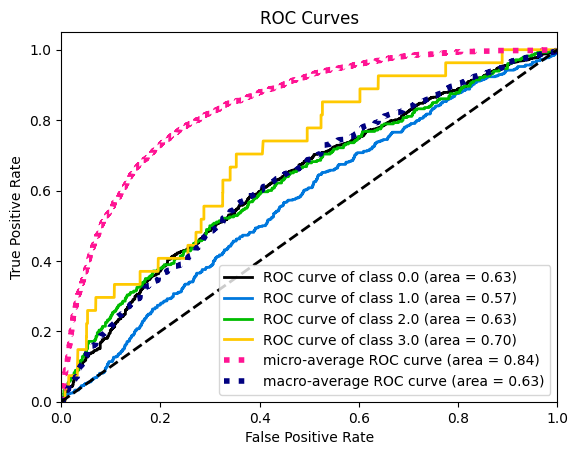

In [20]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

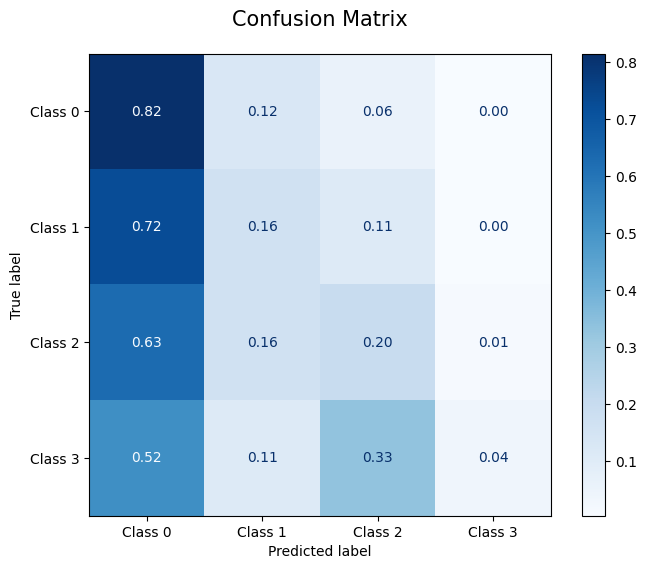

In [21]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

##### Hyperparameter testing

In [23]:
from sklearn.model_selection import GridSearchCV

param_grid = {'learning_rate': [0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0]}

clf_base = GradientBoostingClassifier(n_estimators=100, 
                                      max_depth=3, 
                                      random_state=0)

grid_search = GridSearchCV(clf_base, 
                           param_grid, 
                           cv=5,                    # 5-fold cross-validation
                           scoring='f1_weighted',   # metrica principale
                           n_jobs=-1,               # usa tutti i core
                           verbose=1)

grid_search.fit(X_train_sel, y_train_resampled)

# Risultati ordinati
results_df = pd.DataFrame(grid_search.cv_results_)[
    ['param_learning_rate', 'mean_test_score', 'std_test_score', 'rank_test_score']
].sort_values('rank_test_score')

print(results_df.to_string(index=False))

# Valutazione del modello migliore sul test set
best_clf = grid_search.best_estimator_
y_pred = best_clf.predict(X_test_sel)

print(f"\n✅ Miglior learning_rate: {grid_search.best_params_['learning_rate']}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred, average='weighted'):.4f}")
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 7 candidates, totalling 35 fits
 param_learning_rate  mean_test_score  std_test_score  rank_test_score
               0.500         0.755455        0.139794                1
               1.000         0.749256        0.128224                2
               0.200         0.731726        0.143478                3
               0.100         0.704363        0.129003                4
               0.050         0.662024        0.099518                5
               0.010         0.575486        0.045892                6
               0.001         0.537004        0.034399                7

✅ Miglior learning_rate: 0.5
Accuracy: 0.6458
F1-score: 0.5976
              precision    recall  f1-score   support

         0.0       0.72      0.88      0.79      1749
         1.0       0.25      0.12      0.16       482
         2.0       0.25      0.14      0.18       280
         3.0       0.00      0.00      0.00        27

    accuracy                        

In [24]:
clf = GradientBoostingClassifier(n_estimators=100, 
                                 learning_rate=0.5, max_depth=4, random_state=0)
clf.fit(X_train_sel, y_train_resampled)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.6339637509850276
F1-score [0.78318003 0.19612903 0.18901099 0.        ]
              precision    recall  f1-score   support

         0.0       0.72      0.85      0.78      1749
         1.0       0.26      0.16      0.20       482
         2.0       0.25      0.15      0.19       280
         3.0       0.00      0.00      0.00        27

    accuracy                           0.63      2538
   macro avg       0.31      0.29      0.29      2538
weighted avg       0.58      0.63      0.60      2538



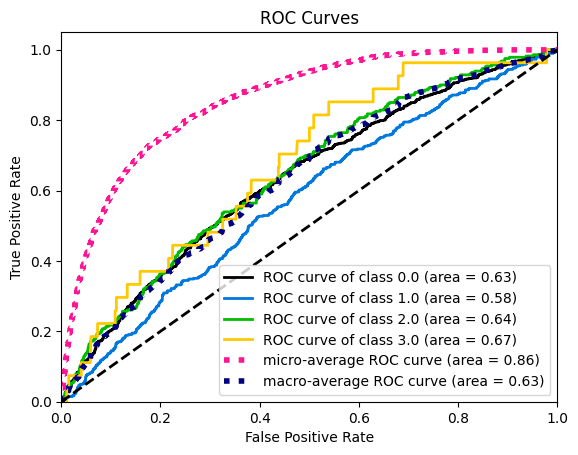

In [25]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

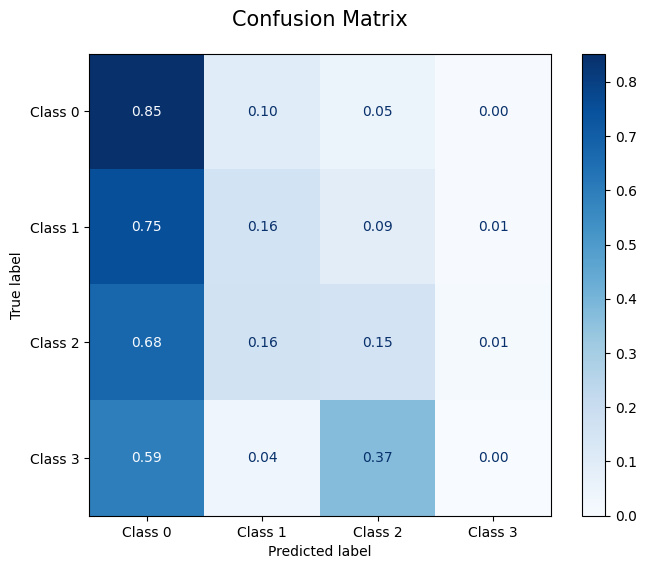

In [26]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

In [27]:
from sklearn.ensemble import HistGradientBoostingClassifier

In [28]:
clf = HistGradientBoostingClassifier(learning_rate=1.0, max_depth=3, random_state=0)
clf.fit(X_train_sel, y_train_resampled)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.6055949566587865
F1-score [0.76233662 0.15789474 0.17821782 0.09677419]
              precision    recall  f1-score   support

         0.0       0.71      0.82      0.76      1749
         1.0       0.22      0.12      0.16       482
         2.0       0.20      0.16      0.18       280
         3.0       0.09      0.11      0.10        27

    accuracy                           0.61      2538
   macro avg       0.30      0.30      0.30      2538
weighted avg       0.56      0.61      0.58      2538



**Hyperparameter testing**

In [28]:
from sklearn.model_selection import GridSearchCV

param_grid = {'learning_rate': [0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0]}

clf_base = HistGradientBoostingClassifier(max_depth=3, random_state=0)

grid_search = GridSearchCV(clf_base, 
                           param_grid, 
                           cv=5,                    # 5-fold cross-validation
                           scoring='f1_weighted',   # metrica principale
                           n_jobs=-1,               # usa tutti i core
                           verbose=1)

grid_search.fit(X_train_sel, y_train_resampled)

# Risultati ordinati
results_df = pd.DataFrame(grid_search.cv_results_)[
    ['param_learning_rate', 'mean_test_score', 'std_test_score', 'rank_test_score']
].sort_values('rank_test_score')

print(results_df.to_string(index=False))

# Valutazione del modello migliore sul test set
best_clf = grid_search.best_estimator_
y_pred = best_clf.predict(X_test_sel)

print(f"\nMiglior learning_rate: {grid_search.best_params_['learning_rate']}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred, average='weighted'):.4f}")
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 7 candidates, totalling 35 fits
 param_learning_rate  mean_test_score  std_test_score  rank_test_score
               0.500         0.839606        0.094597                1
               0.200         0.821100        0.090316                2
               0.100         0.789574        0.082413                3
               0.050         0.751007        0.066836                4
               1.000         0.738764        0.105096                5
               0.010         0.666803        0.026196                6
               0.001         0.609271        0.027764                7

Miglior learning_rate: 0.5
Accuracy: 0.7313
F1-score: 0.7083
              precision    recall  f1-score   support

         0.0       0.79      0.91      0.84      1749
         1.0       0.54      0.34      0.42       482
         2.0       0.53      0.37      0.44       280
         3.0       0.00      0.00      0.00        27

    accuracy                          

In [29]:
clf = HistGradientBoostingClassifier(learning_rate=0.5, max_depth=3, random_state=0)
clf.fit(X_train_sel, y_train_resampled)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.6308116627265563
F1-score [0.78461136 0.15633423 0.1814346  0.05128205]
              precision    recall  f1-score   support

         0.0       0.72      0.86      0.78      1749
         1.0       0.22      0.12      0.16       482
         2.0       0.22      0.15      0.18       280
         3.0       0.08      0.04      0.05        27

    accuracy                           0.63      2538
   macro avg       0.31      0.29      0.29      2538
weighted avg       0.57      0.63      0.59      2538



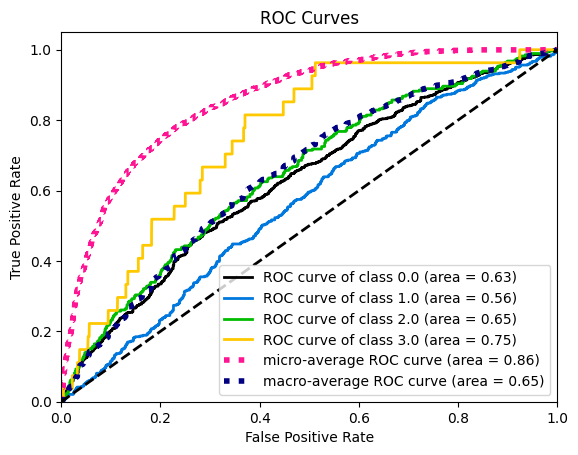

In [30]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

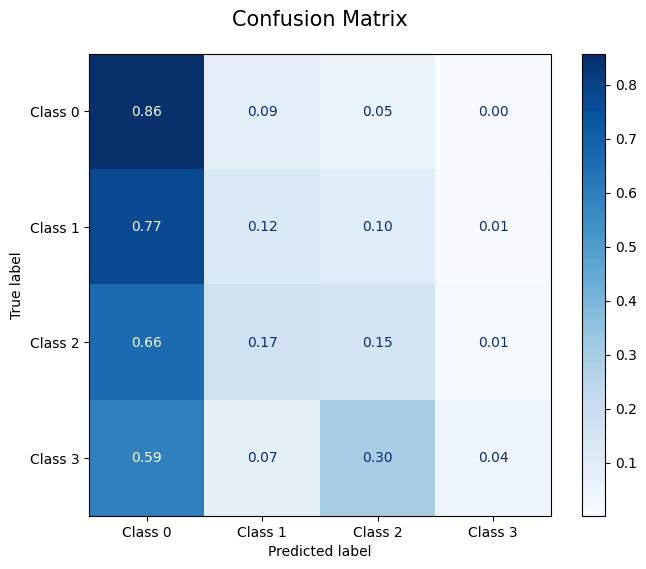

In [31]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

## XGBoost
https://xgboost.readthedocs.io/en/stable/python/python_intro.html

In [ ]:
# !pip install xgboost

In [32]:
from xgboost import XGBClassifier

In [33]:
clf = XGBClassifier(objective='binary:logistic', 
    max_depth = 6,
    learning_rate = 1.0,
    gamma = 0.0,
    reg_lambda = 1,
    tree_method='exact', # 'approx'
    use_label_encoder=False,
    random_state=42
                   )
clf.fit(X_train_sel, y_train_resampled)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:25:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy 0.6308116627265563
F1-score [0.77926159 0.18814433 0.17977528 0.        ]
              precision    recall  f1-score   support

         0.0       0.72      0.85      0.78      1749
         1.0       0.25      0.15      0.19       482
         2.0       0.24      0.14      0.18       280
         3.0       0.00      0.00      0.00        27

    accuracy                           0.63      2538
   macro avg       0.30      0.29      0.29      2538
weighted avg       0.57      0.63      0.59      2538



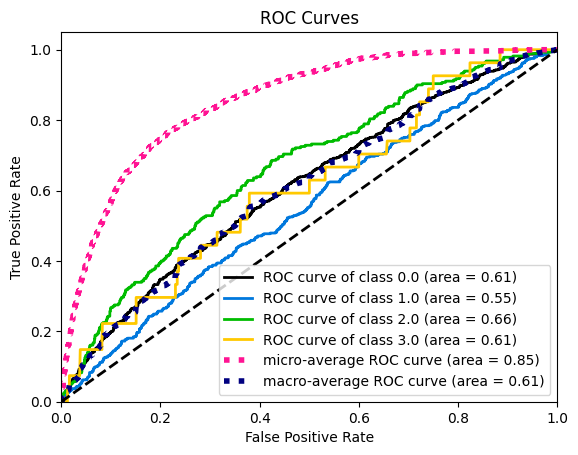

In [34]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

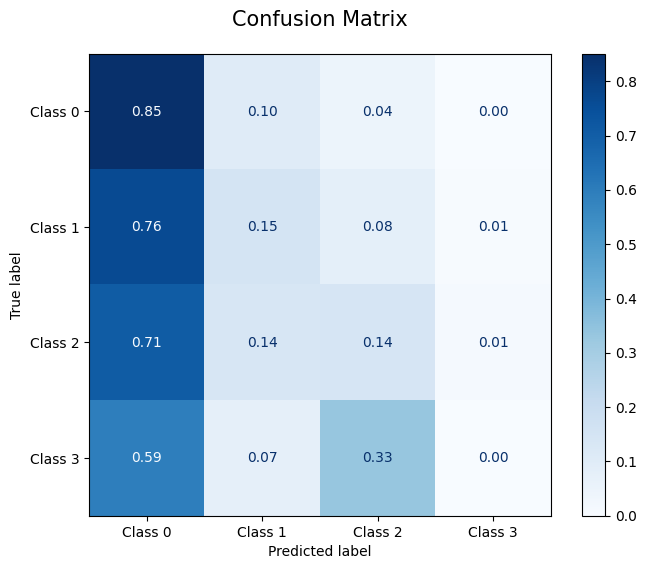

In [39]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

##### Hyperparameter

In [42]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from xgboost import XGBClassifier

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote',  SMOTE(random_state=42)),
    ('selector', SelectFromModel(
        XGBClassifier(random_state=42, eval_metric='logloss')
    )),
    ('xgb', XGBClassifier(
        objective      = 'binary:logistic',
        tree_method    = 'hist',        # più veloce di 'exact'
        eval_metric    = 'logloss',     # evita il warning use_label_encoder
        random_state   = 42,
        n_jobs         = -1
    ))
])

param_grid = {
    'selector__threshold':   ['mean', 'median'],
    'xgb__n_estimators':     [100, 200],
    'xgb__max_depth':        [4, 6],
    'xgb__learning_rate':    [0.05, 0.1],
    'xgb__gamma':            [0.0, 0.5]
}

# Cross-validation stratificata 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearch 
grid_search = GridSearchCV(
    estimator  = pipeline,
    param_grid = param_grid,
    cv         = cv,
    scoring    = 'f1_weighted',
    n_jobs     = -1,
    verbose    = 2         
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'selector__threshold': ['mean', 'median'], 'xgb__gamma': [0.0, 0.5], 'xgb__learning_rate': [0.05, 0.1], 'xgb__max_depth': [4, 6], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about mult

In [43]:
# Extract the Winning Parameters
print(f"Best Parameters found: {grid_search.best_params_}")

Best Parameters found: {'selector__threshold': 'median', 'xgb__gamma': 0.0, 'xgb__learning_rate': 0.1, 'xgb__max_depth': 6, 'xgb__n_estimators': 200}


In [44]:
# Grab the "Winning" model
best_model = grid_search.best_estimator_

# Make predictions on the unseen test data
y_pred = best_model.predict(X_test)
# Get prediction probabilities
y_prob = best_model.predict_proba(X_test)[:, 1]  # Probability of positive class

# 3. The Evaluation Report
print("Final evaluation on test set")
print(f"Best internal CV Score: {grid_search.best_score_:.4f}")

print("\nDetailed Classification Report:")
# This shows Precision, Recall, and F1-Score 
print(classification_report(y_test, y_pred))

Final evaluation on test set
Best internal CV Score: 0.6235

Detailed Classification Report:
              precision    recall  f1-score   support

         0.0       0.73      0.90      0.80      1749
         1.0       0.27      0.13      0.17       482
         2.0       0.30      0.14      0.19       280
         3.0       0.11      0.04      0.06        27

    accuracy                           0.66      2538
   macro avg       0.35      0.30      0.31      2538
weighted avg       0.59      0.66      0.61      2538



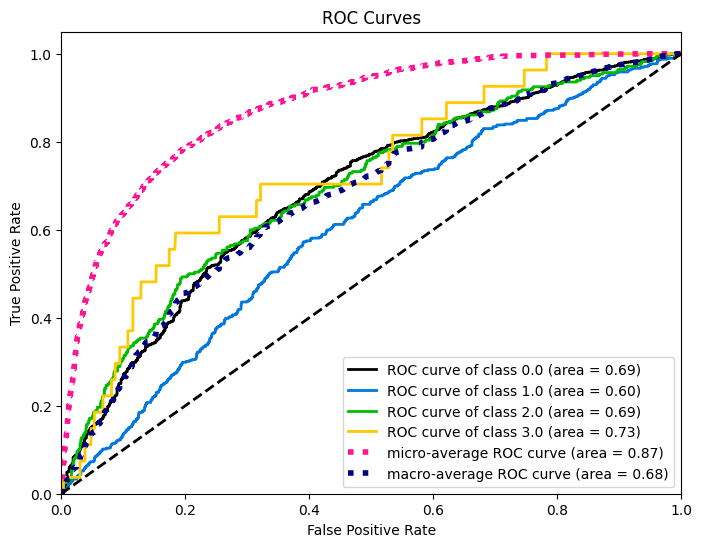

In [45]:
import scikitplot as skplt 

# 1. Get predictions from the BEST model found by GridSearch
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_score = best_model.predict_proba(X_test)

# ROC curve 
# Works for both 2 and 4 classes
skplt.metrics.plot_roc(y_test, y_score, figsize=(8, 6), title="ROC Curves")
plt.show()


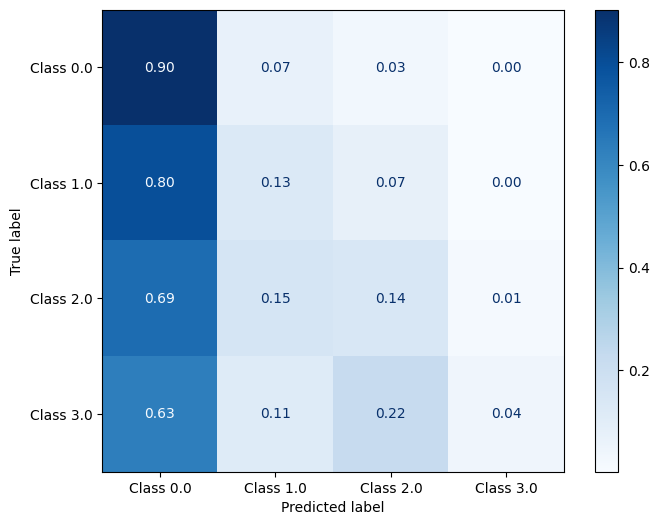

In [46]:
# Confusion Matrix
# Prepare labels dynamically based on current target
unique_classes = sorted(list(set(y_test)))
labels = [f"Class {i}" for i in unique_classes]

# Create the figure
fig, ax = plt.subplots(figsize=(8, 6))

# Use 'normalize=true' to see percentages per row
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=labels, 
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f'
)

# New target variable data preparation 

**Basic_Demos-Enroll_Season**

In [47]:
df['sii']=df_original.loc[df.index, 'sii']
df.head()

,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,...,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,Physical-BMI_New,FGC_SitReach_Avg,FGC_Grip_Avg,PAQ_Total,Endurance_Total_Sec,sii
0,0,5.0,0.0,3,51.00,0,46.000,50.8,26.0,73.9,...,50.55,71.8,0,3,16.877316,6.5,12.3225,2.006,448.0,2.0
1,2,9.0,0.0,1,62.55,0,48.000,46.0,22.0,75.0,...,46.00,64.0,2,0,14.035590,11.0,20.6250,2.010,334.0,0.0
2,2,10.0,1.0,0,71.00,0,56.500,75.6,25.4,65.0,...,38.00,54.0,2,2,16.648696,10.0,12.4500,2.009,453.0,0.0
3,3,9.0,0.0,0,71.00,2,56.000,81.6,26.0,60.0,...,31.00,45.0,3,0,18.292347,7.0,20.6250,2.010,577.0,1.0
4,1,18.0,1.0,2,65.00,1,55.003,77.0,26.0,68.0,...,41.60,61.4,1,1,17.894545,9.1,21.5525,1.040,460.0,0.0


In [48]:
df_Gb = df.copy()

In [49]:
df.drop(columns=['Basic_Demos-Enroll_Season'], inplace=True)

In [50]:
X = df.values
y = np.array(df_Gb['Basic_Demos-Enroll_Season'])

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=100)

In [52]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [53]:
# SMOTE 
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE : {X_train.shape[0]} samples")
print(f"After SMOTE : {X_train_resampled.shape[0]} samples")
print(f"Distribution of classes after SMOTE : {dict(zip(*np.unique(y_train_resampled, return_counts=True)))}")

Before SMOTE : 5922 samples
After SMOTE : 6852 samples
Distribution of classes after SMOTE : {0: 1713, 1: 1713, 2: 1713, 3: 1713}


In [54]:
# SelectFromModel with XGBoost

sel = SelectFromModel(xgb.XGBClassifier(random_state=42))
X_train_sel = sel.fit_transform(X_train_resampled, y_train_resampled)
X_test_sel = sel.transform(X_test)
X_train_sel.shape

(6852, 6)

In [55]:
clf = GradientBoostingClassifier(n_estimators=100, 
                                 learning_rate=1.0, max_depth=3, random_state=0)
clf.fit(X_train_sel, y_train_resampled)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.8022064617809299
F1-score [0.8148855  0.80285344 0.77442274 0.81470588]
              precision    recall  f1-score   support

           0       0.84      0.80      0.81       537
           1       0.77      0.84      0.80       734
           2       0.77      0.78      0.77       562
           3       0.85      0.79      0.81       705

    accuracy                           0.80      2538
   macro avg       0.81      0.80      0.80      2538
weighted avg       0.80      0.80      0.80      2538



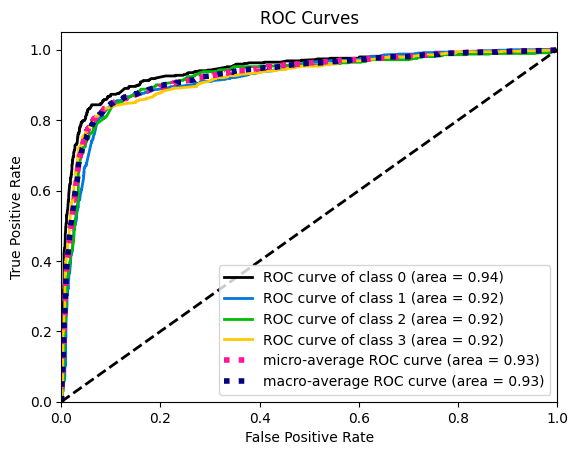

In [56]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

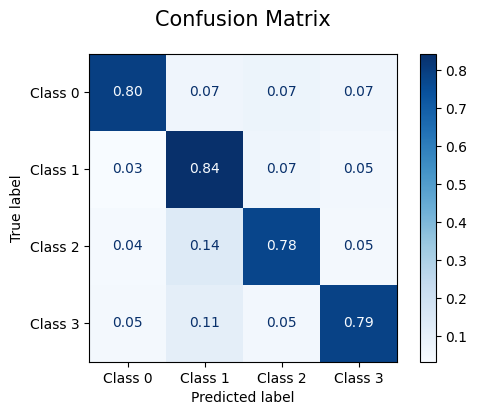

In [57]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(6, 4))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

In [58]:
param_grid = {'learning_rate': [0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0]}

clf_base = GradientBoostingClassifier(n_estimators=100, 
                                      max_depth=3, 
                                      random_state=0)

grid_search = GridSearchCV(clf_base, 
                           param_grid, 
                           cv=5,                    # 5-fold cross-validation
                           scoring='f1_macro',   # metrica principale
                           n_jobs=-1,               # usa tutti i core
                           verbose=1)

grid_search.fit(X_train_sel, y_train_resampled)

# Risultati ordinati
results_df = pd.DataFrame(grid_search.cv_results_)[
    ['param_learning_rate', 'mean_test_score', 'std_test_score', 'rank_test_score']
].sort_values('rank_test_score')

print(results_df.to_string(index=False))

# Valutazione del modello migliore sul test set
best_clf = grid_search.best_estimator_
y_pred = best_clf.predict(X_test_sel)

print(f"\n Miglior learning_rate: {grid_search.best_params_['learning_rate']}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred, average='weighted'):.4f}")
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 7 candidates, totalling 35 fits
 param_learning_rate  mean_test_score  std_test_score  rank_test_score
               0.010         0.829853        0.007363                1
               0.001         0.829242        0.007022                2
               0.050         0.829071        0.008486                3
               0.100         0.828186        0.008247                4
               0.200         0.826804        0.010016                5
               0.500         0.819596        0.008957                6
               1.000         0.809534        0.010603                7

 Miglior learning_rate: 0.01
Accuracy: 0.8255
F1-score: 0.8257
              precision    recall  f1-score   support

           0       0.87      0.82      0.84       537
           1       0.79      0.86      0.82       734
           2       0.80      0.81      0.80       562
           3       0.86      0.81      0.83       705

    accuracy                        

In [60]:
clf = GradientBoostingClassifier(n_estimators=100, 
                                 learning_rate=0.01, max_depth=3, random_state=0)
clf.fit(X_train_sel, y_train_resampled)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average="macro"))
print(classification_report(y_test, y_pred))

Accuracy 0.8254531126871553
F1-score 0.8257538656402377
              precision    recall  f1-score   support

           0       0.87      0.82      0.84       537
           1       0.79      0.86      0.82       734
           2       0.80      0.81      0.80       562
           3       0.86      0.81      0.83       705

    accuracy                           0.83      2538
   macro avg       0.83      0.82      0.83      2538
weighted avg       0.83      0.83      0.83      2538



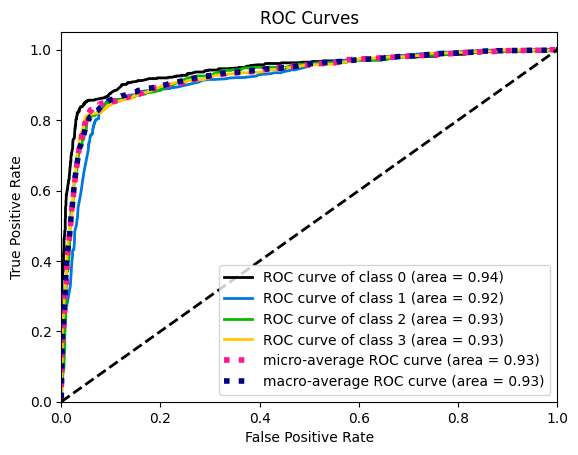

In [61]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

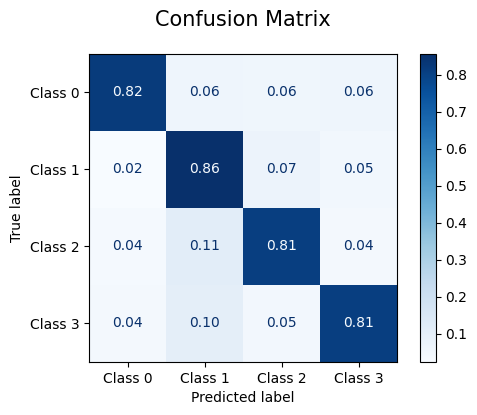

In [62]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(6, 4))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

## LightGBM
https://lightgbm.readthedocs.io/en/latest/Python-Intro.html

In [63]:
from lightgbm import LGBMClassifier

**Basic_Demos-Sex**

In [64]:
df["Basic_Demos-Enroll_Season"] = df_Gb["Basic_Demos-Enroll_Season"]
df.head()

,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,...,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,Physical-BMI_New,FGC_SitReach_Avg,FGC_Grip_Avg,PAQ_Total,Endurance_Total_Sec,sii,Basic_Demos-Enroll_Season
0,5.0,0.0,3,51.00,0,46.000,50.8,26.0,73.9,85.6,...,71.8,0,3,16.877316,6.5,12.3225,2.006,448.0,2.0,0
1,9.0,0.0,1,62.55,0,48.000,46.0,22.0,75.0,70.0,...,64.0,2,0,14.035590,11.0,20.6250,2.010,334.0,0.0,2
2,10.0,1.0,0,71.00,0,56.500,75.6,25.4,65.0,94.0,...,54.0,2,2,16.648696,10.0,12.4500,2.009,453.0,0.0,2
3,9.0,0.0,0,71.00,2,56.000,81.6,26.0,60.0,97.0,...,45.0,3,0,18.292347,7.0,20.6250,2.010,577.0,1.0,3
4,18.0,1.0,2,65.00,1,55.003,77.0,26.0,68.0,77.9,...,61.4,1,1,17.894545,9.1,21.5525,1.040,460.0,0.0,1


In [65]:
df_lightGb = df.copy()

In [75]:
df_lightGb.drop(columns=['Basic_Demos-Sex'], inplace=True)

In [77]:
df_lightGb

,Basic_Demos-Age,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,...,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,Physical-BMI_New,FGC_SitReach_Avg,FGC_Grip_Avg,PAQ_Total,Endurance_Total_Sec,sii,Basic_Demos-Enroll_Season
0,5.0,3,51.00,0,46.000,50.8,26.000,73.90,85.6,114.00,...,71.80,0,3,16.877316,6.5,12.3225,2.006,448.0,2.0,0
1,9.0,1,62.55,0,48.000,46.0,22.000,75.00,70.0,122.00,...,64.00,2,0,14.035590,11.0,20.6250,2.010,334.0,0.0,2
2,10.0,0,71.00,0,56.500,75.6,25.400,65.00,94.0,117.00,...,54.00,2,2,16.648696,10.0,12.4500,2.009,453.0,0.0,2
3,9.0,0,71.00,2,56.000,81.6,26.000,60.00,97.0,117.00,...,45.00,3,0,18.292347,7.0,20.6250,2.010,577.0,1.0,3
4,18.0,2,65.00,1,55.003,77.0,26.000,68.00,77.9,112.35,...,61.40,1,1,17.894545,9.1,21.5525,1.040,460.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8455,7.0,1,65.15,0,46.070,49.0,22.250,58.50,82.5,104.75,...,55.00,1,0,16.229868,7.0,18.0750,2.000,547.7,0.0,1
8456,10.0,1,69.50,3,56.130,47.8,28.500,66.00,80.5,107.50,...,56.95,3,0,10.665793,5.0,13.5750,2.000,451.5,1.0,3
8457,10.0,3,70.00,3,49.560,47.2,25.635,63.50,83.5,119.50,...,60.75,1,2,13.509359,9.5,21.0375,2.004,528.0,0.0,3
8458,15.0,1,55.50,1,63.790,99.5,31.100,67.70,87.5,108.00,...,56.15,0,1,17.189894,10.5,24.4700,2.000,478.0,2.0,0


In [78]:
X = df_lightGb.values
y = np.array(df_original['Basic_Demos-Sex'])

In [79]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=100)

In [80]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

#### Smote

In [81]:
# SMOTE 
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE : {X_train.shape[0]} samples")
print(f"After SMOTE : {X_train_resampled.shape[0]} samples")
print(f"Distribution of classes after SMOTE : {dict(zip(*np.unique(y_train_resampled, return_counts=True)))}")

Before SMOTE : 5922 samples
After SMOTE : 7080 samples
Distribution of classes after SMOTE : {0: 3540, 1: 3540}


In [82]:
# SelectFromModel with XGBoost

sel = SelectFromModel(xgb.XGBClassifier(random_state=42))
X_train_sel = sel.fit_transform(X_train_resampled, y_train_resampled)
X_test_sel = sel.transform(X_test)
X_train_sel.shape

(7080, 19)

In [83]:
clf = LGBMClassifier(boosting_type='gbdt',  #'goss', #'dart'
                     max_depth=-1, # no limit
                     num_leaves=31,
                     n_estimators=100,
                     subsample_for_bin=200000,
                     objective='binary',
                     reg_alpha=0.0, #L1 regularization term on weights
                     reg_lambda=0.0, #L2 regularization term on weights
                     random_state=42
                   )
clf.fit(X_train_sel, y_train_resampled)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average="macro"))
print(classification_report(y_test, y_pred))

[LightGBM] [Info] Number of positive: 3540, number of negative: 3540
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0,000733 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4087
[LightGBM] [Info] Number of data points in the train set: 7080, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0,500000 -> initscore=0,000000
Accuracy 0.7438928289992119
F1-score 0.7276394227943531
              precision    recall  f1-score   support

           0       0.76      0.83      0.79      1516
           1       0.71      0.62      0.66      1022

    accuracy                           0.74      2538
   macro avg       0.74      0.72      0.73      2538
weighted avg       0.74      0.74      0.74      2538



c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


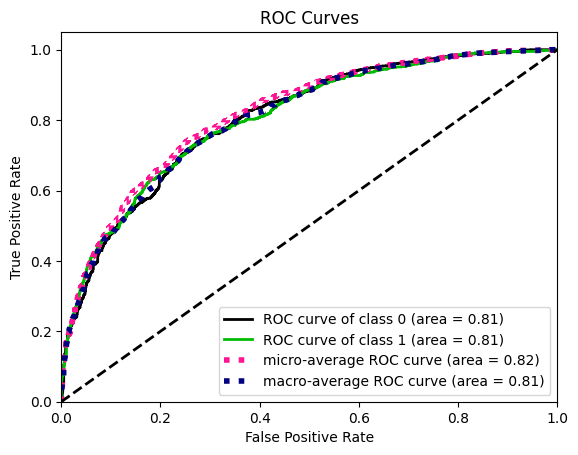

In [84]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

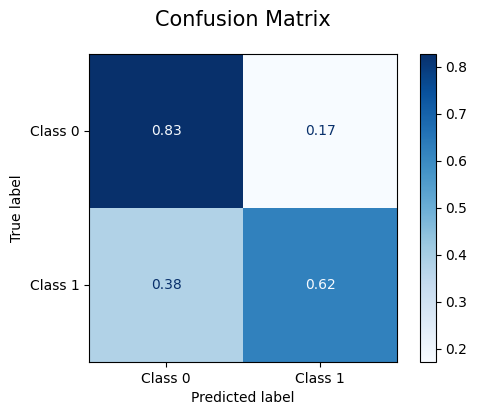

In [85]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(6, 4))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()